## Variational Autoencoder 

In [1]:
print('connected to kernel')

connected to kernel


**Inserting Libraries**

In [2]:
import numpy as np
import pandas as pd
import uproot
import matplotlib.pyplot as plt
import os

In [3]:
import numpy as np
import pandas as pd
import uproot
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)
import keras
from keras import ops
from keras import layers
os.environ["KERAS_BACKEND"] = "tensorflow"


**Loading the File and Identifying its contents**

In [4]:
root_file_name = "/Users/ruthhodgson/geant4_apps/QEPET/build/out.root"

root_file = uproot.open(root_file_name)

trees = root_file.keys()
print(list(enumerate(trees)))

tree = root_file[trees[11]] #this corresponds to threeG NCS
info = tree.keys()
print(info)

[(0, 'TwoG_NCS;1'), (1, 'TwoG_PhantomSCS;1'), (2, 'TwoG_ScannerSCS;1'), (3, 'TwoG_PhantomSCS_ScannerSCS;1'), (4, 'TwoG_PhantomDCS;1'), (5, 'TwoG_ScannerDCS;1'), (6, 'TwoG_PhantomSCS_ScannerDCS;1'), (7, 'TwoG_PhantomDCS_ScannerSCS;1'), (8, 'TwoG_PhantomDCS_ScannerDCS;1'), (9, 'TwoG_MCS;1'), (10, 'TwoG_Excluded;1'), (11, 'ThreeG_NCS;1'), (12, 'ThreeG_ScannerSCS;1'), (13, 'ThreeG_ScannerDCS;1'), (14, 'ThreeG_ScannerTCS;1'), (15, 'ThreeG_MCS;1'), (16, 'ThreeG_Excluded;1'), (17, 'Run;1')]
['EventID', 'NGammas', 'AnnihilX_mm', 'AnnihilY_mm', 'AnnihilZ_mm', 'GammaIndex', 'GammaTrackID', 'GammaParentID', 'HitIndex', 'VolumeID', 'VolumeName', 'ProcessID', 'ProcessName', 'EnergyDeposit_keV', 'PreEnergy_keV', 'PostEnergy_keV', 'X_mm', 'Y_mm', 'Z_mm', 'Theta_deg', 'Phi_deg', 'DeltaPhi01_deg', 'DeltaPhi02_deg', 'DeltaPhi12_deg']


**Convert this data into a dataframe**

In [5]:
df = tree.arrays(info, library = 'pd')
print(df[['AnnihilX_mm', 'AnnihilY_mm', 'AnnihilZ_mm', 'X_mm', "Y_mm", "Z_mm"]].head(1))

#num of detector hits = number of events / 3

print()

print("Number of detector hits (this is the number of detections) =", len(df))

print()

# num = file['Run'].arrays('NumberOfEvents') 
print("Number of events (this is the number of annihilations) =",
      df['EventID'].drop_duplicates().shape[0])


   AnnihilX_mm  AnnihilY_mm  AnnihilZ_mm       X_mm       Y_mm       Z_mm
0    -0.293905     4.053828    -8.090448  35.348804 -11.452375 -38.762901

Number of detector hits (this is the number of detections) = 14172

Number of events (this is the number of annihilations) = 4724


In [6]:
detects = []
targets = []

annils = df.groupby('EventID', sort = False)
for i , (event_id, event) in enumerate(annils):
    target = [
        event['AnnihilX_mm'].iloc[0],
        event['AnnihilY_mm'].iloc[0],
        event['AnnihilZ_mm'].iloc[0]
    ]

    x1_detect = event['X_mm'].iloc[0]
    x2_detect = event['X_mm'].iloc[1]
    x3_detect = event['X_mm'].iloc[2]

    y1_detect = event['Y_mm'].iloc[0]
    y2_detect = event['Y_mm'].iloc[1]
    y3_detect = event['Y_mm'].iloc[2]

    z1_detect = event['Z_mm'].iloc[0]
    z2_detect = event['Z_mm'].iloc[1]
    z3_detect = event['Z_mm'].iloc[2]

    detect = [
        [x1_detect, y1_detect, z1_detect], 
        [x2_detect, y2_detect, z2_detect], 
        [x3_detect, y3_detect, z3_detect]
    ]

    detects.append(detect)
    targets.append(target)

#convert to arrays

detects = np.array(detects, dtype=np.float16)
targets = np.array(targets, dtype=np.float32)

print(f'Detections shape = {detects.shape}')
print(f'Targets shape = {targets.shape}')


Detections shape = (4724, 3, 3)
Targets shape = (4724, 3)


In [7]:
#print examples to test the data has been set up correctly
print('Correct Annihilations')
print(df[['AnnihilX_mm', 'AnnihilY_mm', 'AnnihilZ_mm']].head(1))
print('Correct Detections')
print(df[['X_mm', "Y_mm", "Z_mm"]].head(3))

print("\nExample Annihilations:")
print(targets[0])
print('Example Detections')
print(detects[0])


Correct Annihilations
   AnnihilX_mm  AnnihilY_mm  AnnihilZ_mm
0    -0.293905     4.053828    -8.090448
Correct Detections
        X_mm       Y_mm       Z_mm
0  35.348804 -11.452375 -38.762901
1  17.195129 -35.946274  32.120178
2 -44.458641  39.904507   1.532497

Example Annihilations:
[-0.29390496  4.0538282  -8.090448  ]
Example Detections
[[ 35.34  -11.45  -38.75 ]
 [ 17.19  -35.94   32.12 ]
 [-44.47   39.9     1.532]]


In [8]:

input_train, input_test, out_train, out_test = train_test_split(
    detects, targets, test_size = 0.2, random_state = 42
)

print(input_train.shape)
print(input_test.shape)
print(out_train.shape)
print(out_test.shape)

(3779, 3, 3)
(945, 3, 3)
(3779, 3)
(945, 3)


In [9]:
#split into batches and scale output

my_batch_size = 16
target_scaler = StandardScaler()



train_dataset = (
    tf.data.Dataset.from_tensor_slices(
        (input_train, out_train)
    )
    .shuffle(len(input_train))
    .batch(my_batch_size)
)

test_dataset = (
    tf.data.Dataset.from_tensor_slices(
        (input_test, out_test)
    )
    .batch(my_batch_size)
)
#scaling will get each value to be centered around 0



**Building the Vae**

In [10]:
#start with the sampling layer
#the call function gives you the variables needed to define the loss function later in the model

latent_dim = 32

class Sampling(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.seed_generator = keras.random.SeedGenerator(annils.ngroups)

    def call(self, inputs):
        z_mean , z_log_var = inputs
        batch = ops.shape(z_mean)[0]
        dimension = ops.shape(z_mean)[1]
        epsilon = keras.random.normal(shape=(batch, dimension), seed = self.seed_generator)
        return z_mean + ops.exp(.5*z_log_var)*epsilon

#encoding layer

encode_inputs = keras.Input(shape=(3, 3))


input = layers.Dense(16, activation= 'relu')(encode_inputs)
input = layers.Dense(16, activation = 'relu')(input)

input = layers.GlobalAveragePooling1D()(input)

input = layers.Dense(16, activation = 'relu')(input)


z_mean = layers.Dense(latent_dim, name = 'z_mean')(input)
z_log_var = layers.Dense(latent_dim, name='z_log_var')(input)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(encode_inputs, [z_mean, z_log_var, z], name = 'encoder')
encoder.summary()




Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 3, 3)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 3, 16)     │         64 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3, 16)     │        272 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 16)        │          0 │ dense_1[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        272 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 32)        │        544 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 32)        │        544 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 32)        │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,696 (6.62 KB)

 Trainable params: 1,696 (6.62 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
#decoder 

latent_inputs = keras.Input(shape=( latent_dim,))
input=layers.Dense(16, activation='relu')(latent_inputs)
input=layers.Dense(16, activation='relu')(input)


decode_outputs = layers.Dense(3)(input)
decoder = keras.Model(latent_inputs, decode_outputs, name = 'decoder')
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 851 (3.32 KB)

 Trainable params: 851 (3.32 KB)

 Non-trainable params: 0 (0.00 B)

**VAE**

In [24]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder= encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name = 'total_loss')
        self.learning_loss_tracker = keras.metrics.Mean(name = "learning_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name='kl_loss')
    @property
    def metrics(self):
        return[
            self.total_loss_tracker,
            self.learning_loss_tracker,
            self.kl_loss_tracker
        ]

    def train_step(self, data):
        hits, anns = data
        with tf.GradientTape() as tape:
            z_mean, z_log_var , z = self.encoder(hits)
            learning_output = self.decoder(z)
            learning_loss = ops.mean(ops.square(learning_output- anns))
                
            kl_loss = -0.5*(1+z_log_var - ops.square(z_mean)-ops.exp(z_log_var))
            kl_loss = ops.mean(ops.sum(kl_loss, axis = 1))

            loss = learning_loss + kl_loss
        
        gradients = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))
        self.total_loss_tracker.update_state(loss)
        self.learning_loss_tracker.update_state(learning_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss":self.total_loss_tracker.result(),
            "learning_loss":self.learning_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()
        }

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)

**Training this vae**

In [25]:
print(type(input_train), type(out_train))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [26]:
# input_data = np.concatenate([input_train, input_test], axis = 0)

vae = VAE(encoder, decoder)
vae.compile(optimizer= keras.optimizers.Adam())
history = vae.fit(train_dataset, epochs = 10, batch_size = my_batch_size)

Epoch 1/10


/Users/ruthhodgson/Documents/l2/coding/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


237/237 ━━━━━━━━━━━━━━━━━━━━ 3s 836us/step - kl_loss: 6.6923e-04 - learning_loss: 4.6979 - loss: 4.6985
Epoch 2/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 908us/step - kl_loss: 5.8963e-04 - learning_loss: 4.7079 - loss: 4.7085
Epoch 3/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 984us/step - kl_loss: 5.6326e-04 - learning_loss: 4.7167 - loss: 4.7172
Epoch 4/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 833us/step - kl_loss: 4.3395e-04 - learning_loss: 4.6834 - loss: 4.6838
Epoch 5/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 794us/step - kl_loss: 4.5776e-04 - learning_loss: 4.6865 - loss: 4.6869
Epoch 6/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 848us/step - kl_loss: 4.3922e-04 - learning_loss: 4.6714 - loss: 4.6718
Epoch 7/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 986us/step - kl_loss: 3.8440e-04 - learning_loss: 4.6864 - loss: 4.6867
Epoch 8/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 916us/step - kl_loss: 3.2305e-04 - learning_loss: 4.6921 - loss: 4.6924
Epoch 9/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 892us/step - kl_loss: 3.6321e-04 - learning_loss

In [15]:
fontsize = 15
linewidth = 1
import matplotlib as mpl
mpl.rcParams['axes.linewidth'] = linewidth
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['xtick.labelsize'] = fontsize
mpl.rcParams['ytick.labelsize'] = fontsize
mpl.rcParams['font.size'] = fontsize
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['axes.formatter.use_mathtext']=True
mpl.rcParams['savefig.bbox'] = 'tight'
mpl.rcParams['mathtext.fontset'] = 'custom'
mpl.rcParams['mathtext.rm'] = 'Times New Roman'
mpl.rcParams['mathtext.it'] = 'Times New Roman'
mpl.rcParams['mathtext.bf'] = 'Times New Roman'

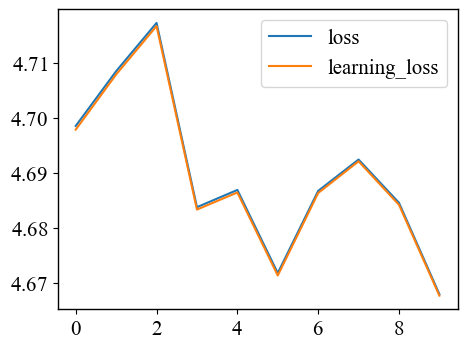

In [27]:
fig, ax0 = plt.subplots(figsize=(4,3))
ax0.set_visible = False
ax1 = fig.add_axes((0,0,1,1))
ax1.plot(history.history['loss'], label = 'loss')
ax1.plot(history.history['learning_loss'], label = 'learning_loss')
# ax1.plot(history.history['kl_loss'], label = 'kl_loss')
ax1.legend()

In [28]:
prediction = vae.predict(input_test)

print(prediction.shape)
print(prediction[:5])

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
(945, 3)
[[ 2.085326   3.1882997 -8.990124 ]
 [ 1.9280497  2.9441247 -8.155746 ]
 [ 1.8981069  2.9492495 -8.207496 ]
 [ 2.0456295  3.0059237 -8.456164 ]
 [ 2.0208268  3.0346994 -8.680374 ]]


In [32]:
for i in range(5):
    print(f'True      : {out_test[i]}')
    print(f'Prediction: {prediction[i]}')
    print()

True      : [  3.9668674   -0.14068586 -11.376202  ]
Prediction: [ 2.085326   3.1882997 -8.990124 ]

True      : [ 2.7431226  6.9315124 -7.3705173]
Prediction: [ 1.9280497  2.9441247 -8.155746 ]

True      : [ 0.01365993 -1.55306    -6.5534334 ]
Prediction: [ 1.8981069  2.9492495 -8.207496 ]

True      : [-1.0098882  0.9581149 -7.2366204]
Prediction: [ 2.0456295  3.0059237 -8.456164 ]

True      : [ 0.9073846  -0.41132656 -6.617211  ]
Prediction: [ 2.0208268  3.0346994 -8.680374 ]



In [33]:
position_error = prediction[:,:3] - out_test[:,:3]


distance_error = np.sqrt(
    position_error[:,0]**2 +
    position_error[:,1]**2 +
    position_error[:,2]**2
)


print(
    "Mean annihilation position error:",
    np.mean(distance_error),
    "mm"
)

Mean annihilation position error: 3.6561472 mm


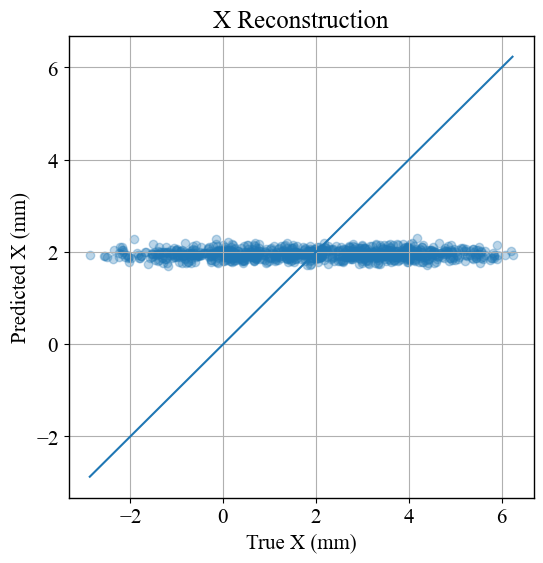

In [36]:
# X
plt.figure(figsize=(6,6))

plt.scatter(
    out_test[:,0],
    prediction[:,0],
    alpha=0.3
)

plt.xlabel("True X (mm)")
plt.ylabel("Predicted X (mm)")
plt.title("X Reconstruction")

plt.plot(
    [out_test[:,0].min(), out_test[:,0].max()],
    [out_test[:,0].min(), out_test[:,0].max()]
)

plt.grid()
plt.show()

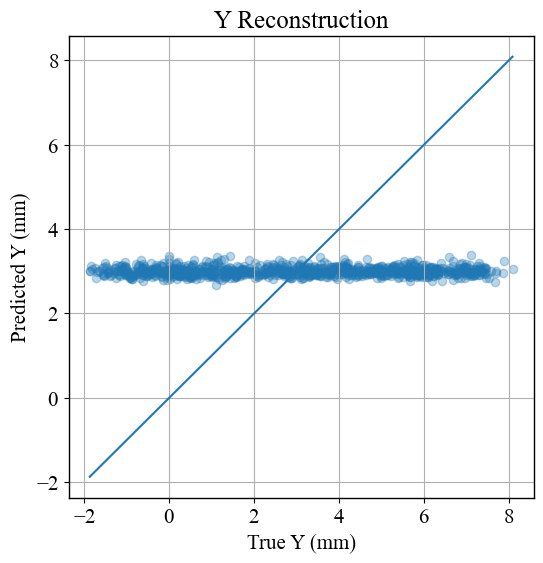

In [37]:
# X
plt.figure(figsize=(6,6))

plt.scatter(
    out_test[:,1],
    prediction[:,1],
    alpha=0.3
)

plt.xlabel("True Y (mm)")
plt.ylabel("Predicted Y (mm)")
plt.title("Y Reconstruction")

plt.plot(
    [out_test[:,1].min(), out_test[:,1].max()],
    [out_test[:,1].min(), out_test[:,1].max()]
)

plt.grid()
plt.show()

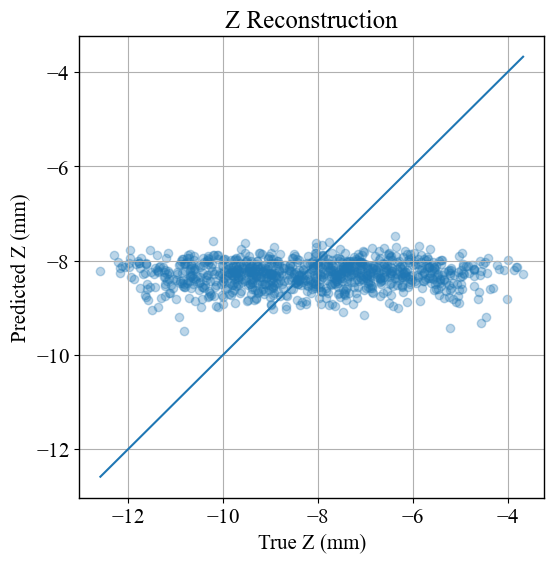

In [38]:
# X
plt.figure(figsize=(6,6))

plt.scatter(
    out_test[:,2],
    prediction[:,2],
    alpha=0.3
)

plt.xlabel("True Z (mm)")
plt.ylabel("Predicted Z (mm)")
plt.title("Z Reconstruction")

plt.plot(
    [out_test[:,2].min(), out_test[:,2].max()],
    [out_test[:,2].min(), out_test[:,2].max()]
)

plt.grid()
plt.show()

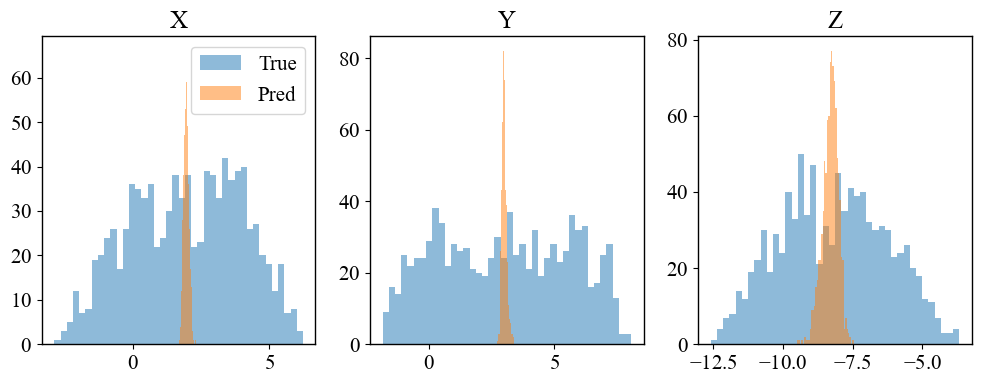

In [39]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.hist(out_test[:,0], bins=40, alpha=0.5, label="True")
plt.hist(prediction[:,0], bins=40, alpha=0.5, label="Pred")
plt.title("X")

plt.legend()

plt.subplot(1,3,2)
plt.hist(out_test[:,1], bins=40, alpha=0.5)
plt.hist(prediction[:,1], bins=40, alpha=0.5)
plt.title("Y")

plt.subplot(1,3,3)
plt.hist(out_test[:,2], bins=40, alpha=0.5)
plt.hist(prediction[:,2], bins=40, alpha=0.5)
plt.title("Z")

plt.show()

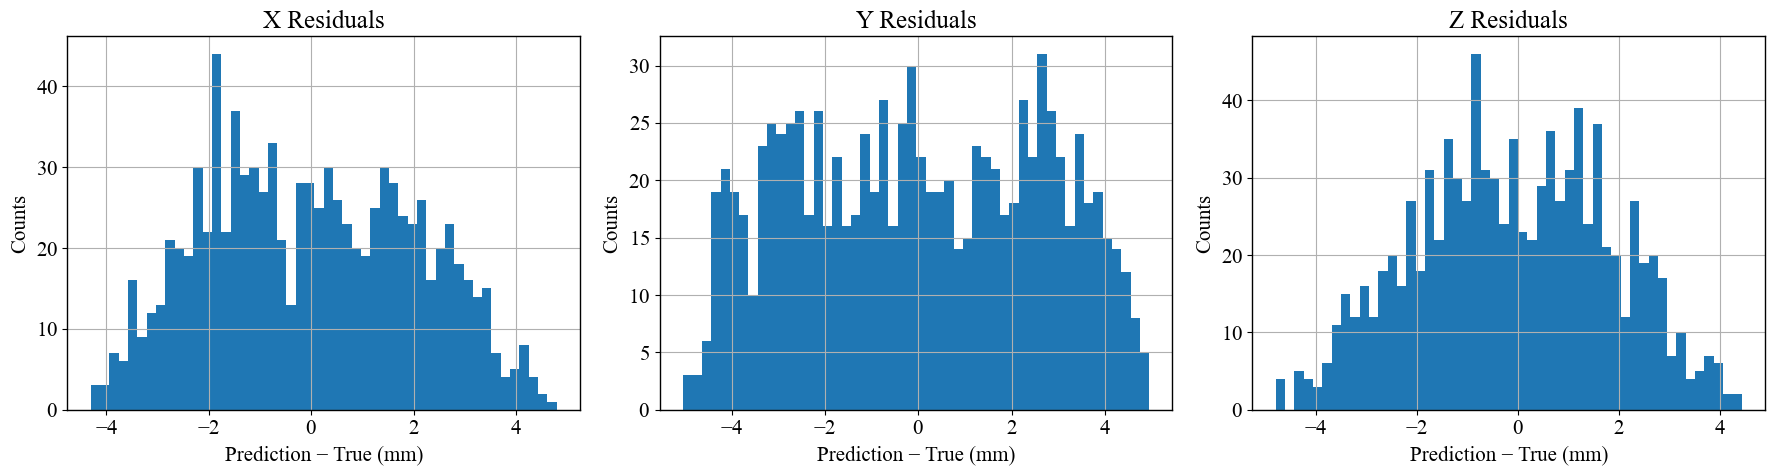

In [40]:
residuals = prediction - out_test
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

coords = ["X", "Y", "Z"]

for i, ax in enumerate(axes):

    ax.hist(
        residuals[:, i],
        bins=50
    )

    ax.set_title(f"{coords[i]} Residuals")
    ax.set_xlabel("Prediction − True (mm)")
    ax.set_ylabel("Counts")
    ax.grid(True)

plt.tight_layout()
plt.show()